<a href="https://colab.research.google.com/github/lxndrkrln/laba_ML/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data = pd.read_csv("heart.csv")
data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [20]:
data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [21]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [31]:
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

In [32]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
data[cols] = data[cols].fillna(data[cols].mean())

In [33]:
cat_cols = []
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object' or dt=='str'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

In [34]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    if col in data.columns:
        mode_val = data[col].mode()[0]
        data[col] = data[col].fillna(mode_val)
        print(f"Столбец '{col}' заполнен значением: {mode_val}")

Столбец 'Sex' заполнен значением: M
Столбец 'ChestPainType' заполнен значением: ASY
Столбец 'RestingECG' заполнен значением: Normal
Столбец 'ExerciseAngina' заполнен значением: N
Столбец 'ST_Slope' заполнен значением: Flat


In [26]:
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [35]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
data_encoded = data.copy()
data_encoded[['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']] = oe.fit_transform(data_encoded[['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']])

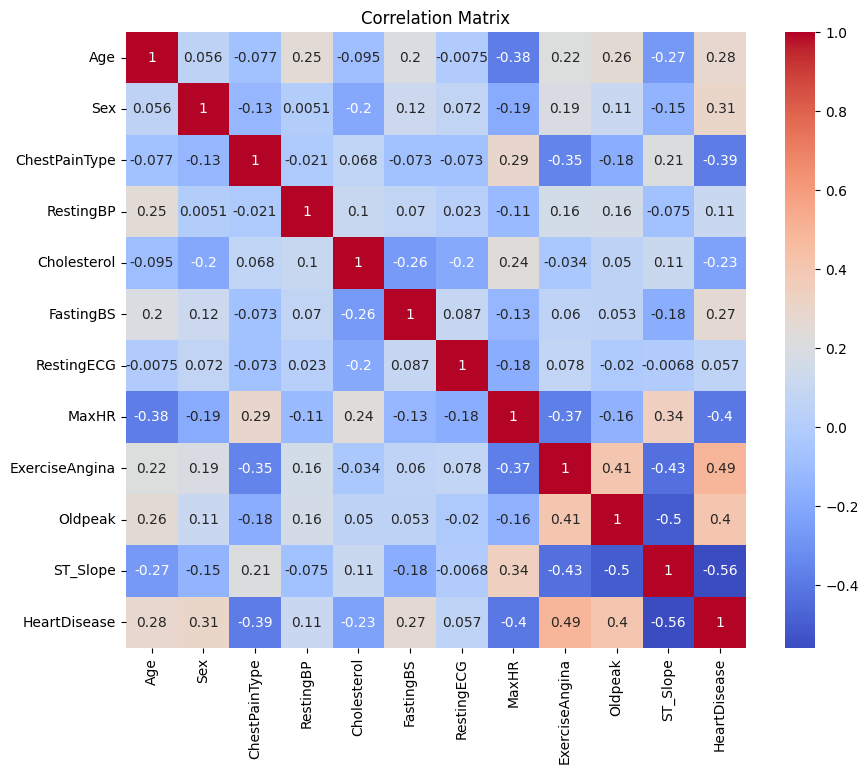

In [36]:
correlation_matrix = data_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [37]:
X = data_encoded.drop(columns=['HeartDisease'])
y = data_encoded['HeartDisease']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Метод ближайших соседей с k = 5

In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score, roc_curve, roc_auc_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.4f}\nRecall: {recall_score(y_test, y_pred):.4f}\nf1_score: {f1_score(y_test, y_pred):.4f}")

Точность: 0.8478
Матрица ошибок:
[[68  9]
 [19 88]]
Precision: 0.9072
Recall: 0.8224
f1_score: 0.8627


# Метод ближайших соседей с подбором гиперпараметра методом GridSearch с помощью кросс-валидации методом StratifiedKFold

In [40]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
n_range = np.array(range(1,30,1))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])}]

In [41]:
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    tuned_parameters,
    cv=cv_stratified,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print(f"Лучший параметр: {grid_search.best_params_}\nЛучшая точность: {grid_search.best_score_:.4f}")

Лучший параметр: {'n_neighbors': np.int64(19)}
Лучшая точность: 0.8624


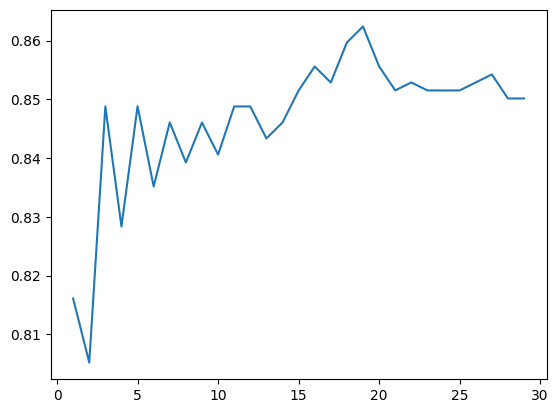

In [42]:
plt.plot(n_range, grid_search.cv_results_['mean_test_score'])

# Метод ближайших соседей с подбором гиперпараметра методом RandomSearch с помощью кросс-валидации методом KFold

In [43]:
random_search = RandomizedSearchCV(
   KNeighborsClassifier(),
    tuned_parameters,
    n_iter=30,
    cv=cv_stratified,
    scoring='accuracy',
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print(f"Лучший параметр: {random_search.best_params_}\nЛучшая точность: {random_search.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 29 is smaller than n_iter=30. Running 29 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Лучший параметр: {'n_neighbors': np.int64(19)}
Лучшая точность: 0.8624


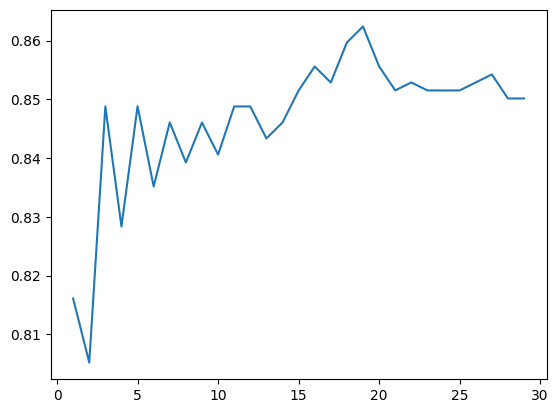

In [44]:
plt.plot(n_range, random_search.cv_results_['mean_test_score'])

In [45]:
from sklearn.model_selection import learning_curve, validation_curve
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.3,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

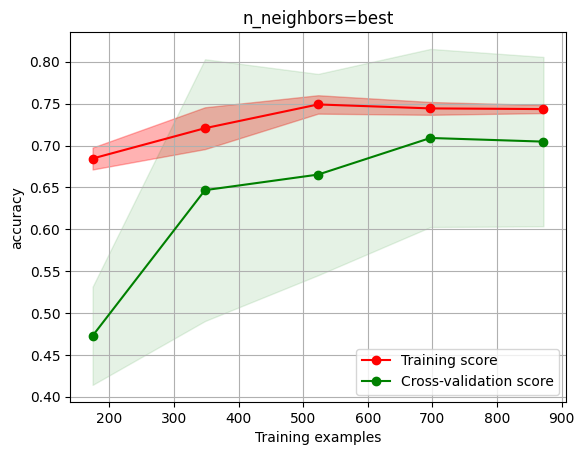

In [46]:
plot_learning_curve(grid_search.best_estimator_, 'n_neighbors=best', X, y, cv=20, train_sizes=np.linspace(.2, 1.0, 5))

In [47]:
def plot_validation_curve(estimator, title, X, y,
                          param_name, param_range, cv,
                          scoring='accuracy'):

    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=1)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel(str(scoring))
    plt.ylim(0.0, 1.1)
    lw = 2
    plt.plot(param_range, train_scores_mean, label="Training score",
                 color="darkorange", lw=lw)
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.4,
                     color="darkorange", lw=lw)
    plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                 color="navy", lw=lw)
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.2,
                     color="navy", lw=lw)
    plt.legend(loc="best")
    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

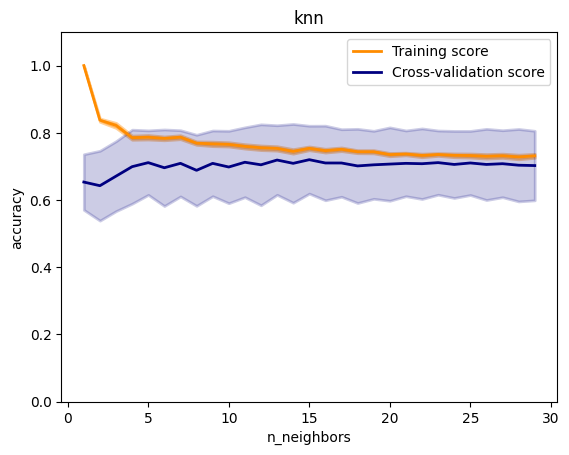

In [48]:
plot_validation_curve(grid_search.best_estimator_, 'knn',
                      X, y,
                      param_name='n_neighbors', param_range=n_range,
                      cv=20, scoring="accuracy")

Точность: 0.8478
Матрица ошибок:
[[68  9]
 [19 88]]
Precision: 0.9072
Recall: 0.8224
f1_score: 0.8627
ROC-AUC: 0.9223


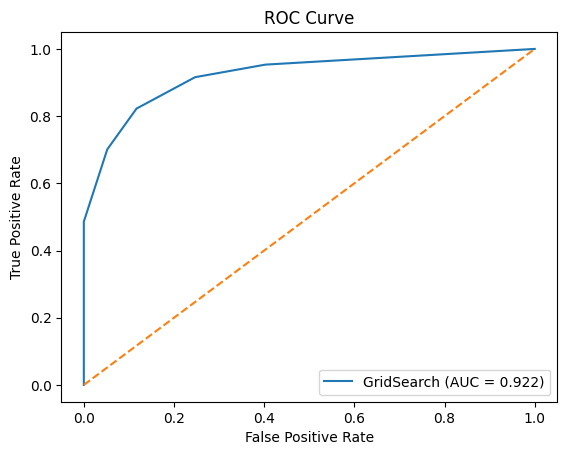

In [49]:
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Точность: {accuracy_score(y_test, y_pred):.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f"Precision: {precision_score(y_test, y_pred):.4f}\nRecall: {recall_score(y_test, y_pred):.4f}\nf1_score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'GridSearch (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Точность: 0.8424
Матрица ошибок:
[[69  8]
 [21 86]]
Precision: 0.9149
Recall: 0.8037
f1_score: 0.8557
ROC-AUC: 0.9402


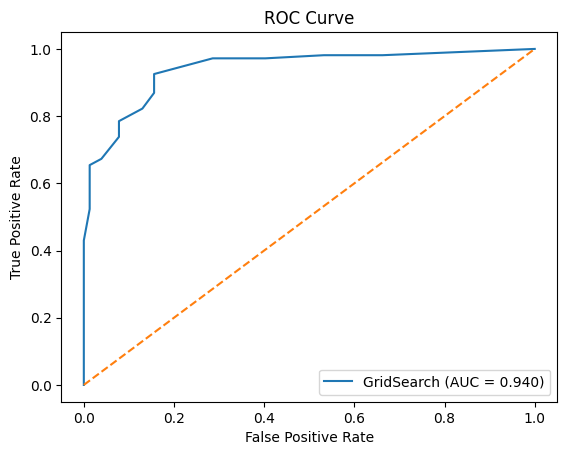

In [50]:
best_knn_grid = grid_search.best_estimator_
y_pred_grid = best_knn_grid.predict(X_test_scaled)
y_proba_grid = best_knn_grid.predict_proba(X_test_scaled)[:, 1]
fpr_grid, tpr_grid, _ = roc_curve(y_test, y_proba_grid)
roc_auc_grid = roc_auc_score(y_test, y_proba_grid)

print(f"Точность: {accuracy_score(y_test, y_pred_grid):.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_grid))
print(f"Precision: {precision_score(y_test, y_pred_grid):.4f}\nRecall: {recall_score(y_test, y_pred_grid):.4f}\nf1_score: {f1_score(y_test, y_pred_grid):.4f}")
print(f"ROC-AUC: {roc_auc_grid:.4f}")

plt.figure()
plt.plot(fpr_grid, tpr_grid, label=f'GridSearch (AUC = {roc_auc_grid:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()